# pyNanoMatBuilder ↔ pyAUSAXS coupling

Minimal tutorial showing how to build a nanoparticle with **pyNanoMatBuilder** and compute its powder X-ray scattering pattern with **pyAUSAXS**.

This is a simple, one-off coupling example — it does **not** cover batch/dataset generation over many NPs.

**Required environment / kernel**: `pyausaxs_env`

Create your environment, for example with conda:

```bash
conda create -n pyausaxs_env python=3.11 -y
conda activate pyausaxs_env
```

Install the dependencies:

```bash
pip install -r requirements-pyausaxs.txt -e .
```

Register the kernel if not already done:
```bash
python -m ipykernel install --user --name pyausaxs_env --display-name "Python (pyausaxs_env)"
```

Make sure this notebook is running on the **pyausaxs_env** kernel before executing the cells below.



## 1. Setup

In [5]:
import pyausaxs
from pyNanoMatBuilder import platonicNPs as pNP
import matplotlib.pyplot as plt
from pyNanoMatBuilder import utils as pyNMBu
import numpy as np

## 2. Build a nanoparticle with pyNanoMatBuilder

In [ ]:
# Gold icosahedron — any other pyNanoMatBuilder shape class works too
AuNP = pNP.regIco(element='Au', Rnn=2.885, nShell=5,
                  postAnalyzis=True, thresholdCoreSurface=1,
                  skipSymmetryAnalyzis=True, aseView=False, noOutput=True)

pyNMBu.write("coords/AuNP_debye.xyz", AuNP.NP)  

print(f"{len(AuNP.NP)} atoms, circumscribed diameter = "
      f"{AuNP.radiusCircumscribedSphere * 2 / 10:.2f} nm")

561 atoms, circumscribed diameter = 2.74 nm


## 3. Compute the scattering pattern with pyAUSAXS



X-ray scattering techniques are powerful tools to probe nanoparticle structure. An incident X‑ray beam is scattered by the sample; the scattered intensity is measured as a function of the magnitude Q of the scattering vector (Q = 4π sinθ / λ, with 2θ the scattering angle and λ the wavelength). At small Q (typically Q 
technique is called SAXS (small‑angle X‑ray scattering) and yields information on size, shape and polydispersity; at larger Q (Q ≳ 1 $Å−1$) it is called W
scattering) and probes atomic arrangements.


The total coherent scattering is given by the Debye formula. Written explicitly:


Equation (1) — full Debye formula
$$
I(Q) \;=\; \sum_{i=1}^{N}\sum_{j=1}^{N} f_i(Q)\,f_j(Q)\,\frac{\sin\bigl(Q\,r_{ij}\bigr)}{Q\,r_{ij}}
$$


This can be split into self and pair contributions:


Equation (2)
$$
I(Q) \;=\; \sum_{i=1}^{N} f_i(Q)^2
\;+\;
2\sum_{i=1}^{N}\sum_{j>i}^{N} f_i(Q)\,f_j(Q)\,\frac{\sin\bigl(Q\,r_{ij}\bigr)}{Q\,r_{ij}}
$$


For large particles the double sum is expensive ($O(N^2)$). A common, efficient approximation is to use an histogram of interatomic distances:


Equation (3) — histogram approximation
$$
I(Q) \;\approx\; \sum_{i=1}^{N} f_i(Q)^2
\;+\;
2\sum_{k=1}^{N_{\mathrm{bins}}} n_k\,f_k^{(2)}(Q)\,\frac{\sin\bigl(Q\,r_k\bigr)}{Q\,r_k}
$$


If all atoms are identical (or if an average form factor f(Q) is used) this simplifies to:


Equation (4) — identical‑atom histogram form
$$
I(Q) \;=\; f(Q)^2\left[\,N \;+\; 2\sum_{k=1}^{N_{\mathrm{bins}}} n_k\,\frac{\sin(Q r_k)}{Q r_k}\right]
$$


Notation: $f_i(Q)$ is the atomic scattering factor of atom $i$; $r_{ij}$ is the interatomic distance between atoms $i$ and $j$; $n_k$ and $r_k$ are the population and
bin $k$; $f_k^{(2)}(Q)$ denotes the appropriate averaged product of form factors for bin $k$.




- `pyAUSAXS` — implements the histogram (distance‑bin) approximation (Equations 3–4). It is much faster for large nanoparticles but requires careful choice of binning parameters for WAXS accuracy.
- For WAXS accuracy, please mind the binning parameters:
- `bin_width` = width of the bin in angstrom, should be chosen according to the size of the NP. Here's some emperical intervals that allow to have an accurate WAXS (obtained from tests, make your own tests):
    - D > 40 nm: width = 0.025 Å
    - 9 nm < D ≤ 40 nm: width = 0.05 Å
    - D ≤ 9 nm: width = 0.1 Å

- `bin_count` = number of bins

Ensure that `bin_width x bin_count > larger dimension of the NP`

Practical recommendations
- Select an appropriate Q range and resolution for your experiment.
- Include atomic form factors and test bin-width and r_max convergence, you can confirm agreement with DebyeCalculator on smaller systems.

You can use `pyAUSAXS` API to compute the scattering intensity step by step (see https://github.com/AUSAXS/pyAUSAXS/blob/master/examples/1_debye_scattering.py) or you can use our function `ausaxs_profile`  which reproduces the same workflow in fewer steps.

Atomic form factor correction applied for Au (f0 at q=0.001 1/A = 78.967)
pyAUSAXS: 561 atoms, 20000 q points in [0.001, 20.0] 1/A, form factors=on


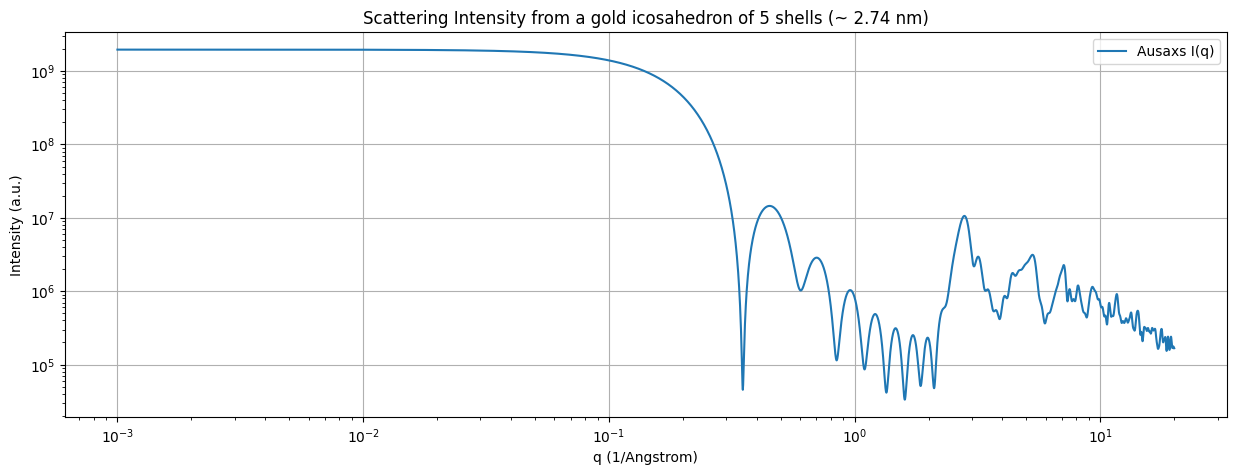

In [7]:
q, iq = AuNP.ausaxs_profile(qmin=0.001, qmax=20.0, npoints=20000, # q range
                            apply_f0=True, # apply atomc form factor f0(q) to the scattering profile (only monoatomic cases for now)
                            threads=None, # number of threads to use for the computation (None = all available)
                            bin_width=0.1, bin_count=1000, # binning parameters for the q-grid 
                            xyz_file="coords/AuNP_ausaxs.xyz", # optional: if you want to write the XYZ file
                            noOutput=False) 

# Save the scattering profile as a text file
# np.savetxt("coords/AuNP_ausaxs.txt", np.column_stack((q, iq)), header="q (1/Angstrom)    Intensity (a.u.)")

# Plot the 
plt.figure(figsize=(15,5))
plt.loglog(q, iq, label="Ausaxs I(q)")
plt.yscale('log')
plt.xlabel('q (1/Angstrom)')
plt.ylabel('Intensity (a.u.)')
plt.title('Scattering Intensity from a gold icosahedron of 5 shells (~ 2.74 nm)')
plt.legend()
plt.grid()
plt.show()
plt.close()

*Note: This simulation corresponds to a single size of icosahedrons. Note that, experimentally, nanoparticles in the sample have different sizes. Indeed, there is a size distribution, and the total measured intensity is a weighted average over the size distribution. Please refer to `pyNMB-tutorials.ipynb` to see how to generate this size polydispersity.*


## 4. Normalization factor

Normalization factor such that $I(q=0) = 1$. It can be useful for comparison purposes with DebyeCalculator or SasView.

**Normalization factors** (monoatomic case):

$$N_{\text{pyAUSAXS}} = \frac{1.6 \times 10^{-4}}{Z^2 N^2}$$

where:
- $Z$ = atomic number of the element
- $N$ = total number of atoms

For polyatomic systems, adapt the formula by replacing $Z^2$ and $N^2$ with appropriate averages or sums over atomic species.

